<a href="https://colab.research.google.com/github/zhiqixie9-jpg/New-York-City-Ride-Hailing-Market-Share-Prediction-Engine/blob/main/Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp "/content/drive/MyDrive/nyc_taxi_dataset_compressed.npz" "/content/nyc_taxi_dataset_compressed.npz"
!cp "/content/drive/MyDrive/market_share.csv.zip" "/content/market_share.csv.zip"
!cp "/content/drive/MyDrive/2025_non_overlap_sample.parquet" "/content/2025_non_overlap_sample.parquet"
!unzip -o "/content/market_share.csv.zip" -d "/content/"
!rm "/content/market_share.csv.zip"

Archive:  /content/market_share.csv.zip
  inflating: /content/market_share.csv/_SUCCESS  
  inflating: /content/market_share.csv/_committed_5735927555225193255  
  inflating: /content/market_share.csv/_started_5735927555225193255  
  inflating: /content/market_share.csv/part-00000-tid-5735927555225193255-47d90cb4-eb5e-47c2-936f-4ffd288b08ca-329-1-c000.csv  


In [ ]:
!pip install catboost
!pip install catboost shap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 6.9 MB/s eta 0:00:00


In [ ]:
!wget -O taxi_zones.zip https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip
!unzip -o taxi_zones.zip -d taxi_zones/
shape_path = "/content/taxi_zones/taxi_zones/taxi_zones.shp"

--2026-05-12 05:25:52--  https://d37ci6vzurychx.cloudfront.net/misc/taxi_zones.zip
Resolving d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)... 3.171.57.190, 3.171.57.69, 3.171.57.103, ...
Connecting to d37ci6vzurychx.cloudfront.net (d37ci6vzurychx.cloudfront.net)|3.171.57.190|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 1022574 (999K) [application/x-zip-compressed]
Saving to: ‘taxi_zones.zip’

taxi_zones.zip      100%[===================>] 998.61K  --.-KB/s    in 0.007s  

2026-05-12 05:25:52 (140 MB/s) - ‘taxi_zones.zip’ saved [1022574/1022574]

Archive:  taxi_zones.zip
  inflating: taxi_zones/taxi_zones/taxi_zones.cpg  
  inflating: taxi_zones/taxi_zones/taxi_zones.dbf  
  inflating: taxi_zones/taxi_zones/taxi_zones.prj  
  inflating: taxi_zones/taxi_zones/taxi_zones.shp  
  inflating: taxi_zones/taxi_zones/taxi_zones.shx  


 New York Ride-Hailing Market Share Prediction Engine 
Draging Meteorological Data from 2025-01-01 to 2026-05-10
OOT Cutting Complete：
   -> Training set: 2025-01-01 ~ 2025-10-31 (1494142 )
   -> Testing set: 2025-11-01 ~ 2025-12-31 (301754 )

Activating 5-Fold Cross-validation Training (Using Logit Spatial Fitting)...
--- Fold 1/5 ---
Fold 1/5 Complete.
--- Fold 2/5 ---
Fold 2/5 Complete.
--- Fold 3/5 ---
Fold 3/5 Complete.
--- Fold 4/5 ---
Fold 4/5 Complete.
--- Fold 5/5 ---
Fold 5/5 Complete.

Training Complete！Final OOF MAE: 0.02694


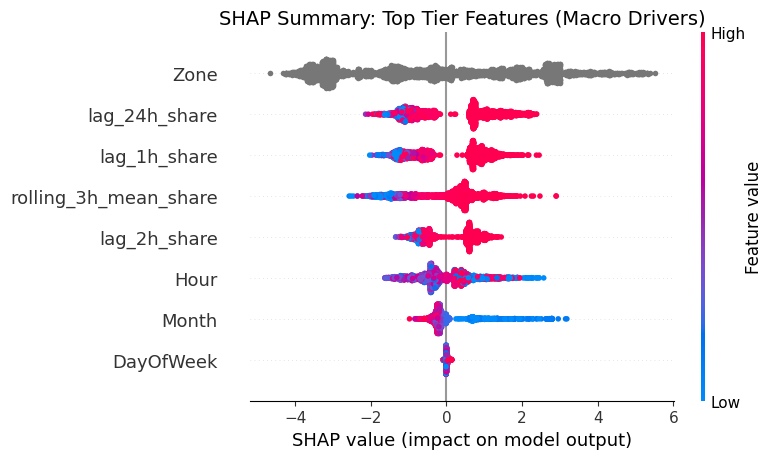

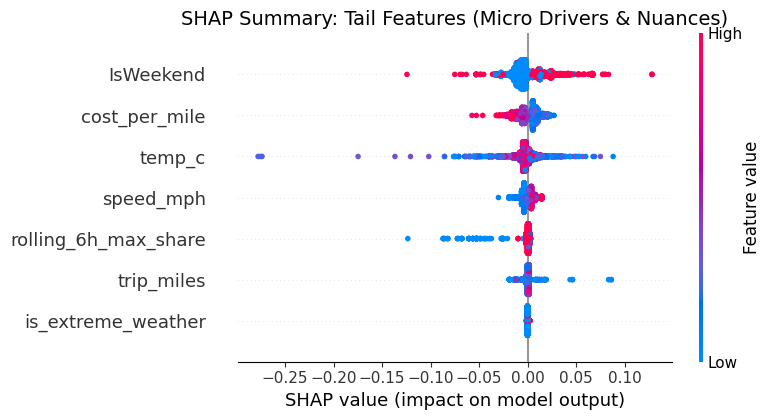


Testing Model's Performance.
OOT Test Set MAE: 0.01161


In [ ]:
import os
import gc
import glob
import requests
import numpy as np
import datetime
import pandas as pd
from scipy.optimize import minimize
from sklearn.model_selection import GroupKFold
from sklearn.metrics import mean_absolute_error
import matplotlib.pyplot as plt
import seaborn as sns
import lightgbm as lgb
from catboost import CatBoostRegressor, Pool
import shap
import warnings
warnings.filterwarnings('ignore')

def logit(y):
    eps = 1e-6
    return np.log((y + eps) / (1 - y + eps))

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def fetch_weather_data(start_date, end_date):
    """Draging Historical Meteorological Data from Open-Meteo"""
    print(f"Draging Meteorological Data from {start_date} to {end_date}")
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude": 40.7128, "longitude": -74.0060,
        "start_date": start_date, "end_date": end_date,
        "hourly": "temperature_2m,precipitation,snowfall",
        "timezone": "America/New_York"
    }
    try:
        response = requests.get(url, params=params).json()
        if "error" in response: return None
        resp = response['hourly']
        weather_df = pd.DataFrame({
            'datetime': pd.to_datetime(resp['time']),
            'temp_c': resp['temperature_2m'],
            'precipitation_mm': resp['precipitation']
        })
        weather_df['Date'] = weather_df['datetime'].dt.date.astype(str)
        weather_df['Hour'] = weather_df['datetime'].dt.hour
        return weather_df.drop(columns=['datetime'])
    except:
        return None

def process_raw_orders(df_raw, geo_mapping, is_full_data=False):
    """Data Preprocessing. Caculating Hvfhv Market Share and other Features."""
    dt = pd.to_datetime(df_raw['pickup_datetime'])
    df_raw['Date'], df_raw['Month'], df_raw['Hour'] = dt.dt.date.astype(str), dt.dt.month, dt.dt.hour
    df_raw['DayOfWeek'], df_raw['IsWeekend'] = dt.dt.dayofweek, dt.dt.dayofweek >= 5

    multiplier = 1.0 if is_full_data else 12.5

    agg_trips = df_raw.groupby(['PULocationID', 'Date', 'Month', 'DayOfWeek', 'Hour', 'IsWeekend', 'trip_type']).size().reset_index(name='sampled_count')
    agg_trips['true_count'] = np.where(agg_trips['trip_type'] == 'rideshare_hvfhv', agg_trips['sampled_count'] * multiplier, agg_trips['sampled_count'])
    total_true = agg_trips.groupby(['PULocationID', 'Date', 'Hour'])['true_count'].transform('sum')
    agg_trips['market_share'] = agg_trips['true_count'] / total_true

    df_target = agg_trips[agg_trips['trip_type'] == 'rideshare_hvfhv'].copy()
    df_target['total_sampled_trips'] = agg_trips.groupby(['PULocationID', 'Date', 'Hour'])['sampled_count'].transform('sum')

    df_rs = df_raw[df_raw['trip_type'] == 'rideshare_hvfhv'].copy()
    df_rs['speed_mph'] = df_rs['trip_miles'] / ((df_rs['trip_time'] / 60.0).replace(0, np.nan))
    df_rs['cost_per_mile'] = df_rs['base_passenger_fare'] / df_rs['trip_miles'].replace(0, np.nan)
    biz_feats = df_rs.groupby(['PULocationID', 'Date', 'Hour']).agg({'speed_mph': 'mean', 'cost_per_mile': 'mean', 'trip_miles': 'mean'}).reset_index()

    df_processed = df_target.merge(biz_feats, on=['PULocationID', 'Date', 'Hour'], how='left').merge(geo_mapping, on='PULocationID', how='left')
    return df_processed

def build_advanced_features(df, weather_df):
    """Building Advanced Features."""
    df = df.merge(weather_df, on=['Date', 'Hour'], how='left')
    df['is_extreme_weather'] = ((df['temp_c'] <= 0) | (df['temp_c'] >= 32) | (df['precipitation_mm'] > 2.5)).astype(int)

    df['datetime'] = pd.to_datetime(df['Date']) + pd.to_timedelta(df['Hour'], unit='h')
    df = df.sort_values(['PULocationID', 'datetime']).reset_index(drop=True)
    for lag in [1, 2, 24]:
        df[f'lag_{lag}h_share'] = df.groupby('PULocationID')['market_share'].shift(lag)
    df['rolling_3h_mean_share'] = df.groupby('PULocationID')['lag_1h_share'].transform(lambda x: x.rolling(3, min_periods=1).mean())
    df['rolling_6h_max_share'] = df.groupby('PULocationID')['lag_1h_share'].transform(lambda x: x.rolling(6, min_periods=1).max())

    df = df[df['total_sampled_trips'] >= 2].copy()
    df['Zone'] = df['Zone'].fillna('Unknown').astype('category')
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    df[numeric_cols] = df[numeric_cols].fillna(-1)
    return df

def train_dual_tower(X, y, groups, categorical_features):
    """Training LightGBM and CatBoost Integration Model."""
    print("\nActivating 5-Fold Cross-validation Training (Using Logit Spatial Fitting)...")
    y_logit = logit(y)
    oof_lgb, oof_cat = np.zeros(len(X)), np.zeros(len(X))
    gkf = GroupKFold(n_splits=5)

    for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups)):
        print(f"--- Fold {fold+1}/5 ---")
        X_tr, y_tr = X.iloc[train_idx], y_logit.iloc[train_idx]
        X_val, y_val_logit = X.iloc[val_idx], y_logit.iloc[val_idx]

        m_lgb = lgb.LGBMRegressor(n_estimators=1000, learning_rate=0.05, num_leaves=127, random_state=42, verbose=-1)
        m_lgb.fit(X_tr, y_tr, eval_set=[(X_val, y_val_logit)], eval_metric='mae', callbacks=[lgb.early_stopping(30, verbose=False)])
        oof_lgb[val_idx] = sigmoid(m_lgb.predict(X.iloc[val_idx]))

        m_cat = CatBoostRegressor(iterations=1000, learning_rate=0.05, depth=8, loss_function='MAE', random_seed=42, verbose=False)
        m_cat.fit(X_tr, y_tr, cat_features=categorical_features, eval_set=Pool(X_val, y_val_logit, cat_features=categorical_features), early_stopping_rounds=30)
        oof_cat[val_idx] = sigmoid(m_cat.predict(X.iloc[val_idx]))
        print(f"Fold {fold+1}/5 Complete.")

    return m_lgb, m_cat, oof_lgb, oof_cat

def generate_dual_shap_plots(model, X_val, cat_features):
    """Visualization."""
    np.random.seed(42)
    sample_idx = np.random.choice(len(X_val), 3000, replace=False)
    X_sample = X_val.iloc[sample_idx]

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(Pool(X_sample, cat_features=cat_features))

    mean_abs_shap = np.abs(shap_values).mean(axis=0)
    sorted_idx = np.argsort(mean_abs_shap)[::-1]

    plt.figure(figsize=(10, 6))
    plt.title("SHAP Summary: Top Tier Features (Macro Drivers)", fontsize=14)
    shap.summary_plot(shap_values[:, sorted_idx[:8]], X_sample.iloc[:, sorted_idx[:8]], show=False)
    plt.tight_layout()
    plt.savefig("shap_macro_drivers.png", dpi=300)
    plt.show()

    plt.figure(figsize=(10, 6))
    plt.title("SHAP Summary: Tail Features (Micro Drivers & Nuances)", fontsize=14)
    shap.summary_plot(shap_values[:, sorted_idx[8:]], X_sample.iloc[:, sorted_idx[8:]], show=False)
    plt.tight_layout()
    plt.savefig("shap_tail_nuances.png", dpi=300)
    plt.show()


if __name__ == "__main__":
    print("=====================================================")
    print(" New York Ride-Hailing Market Share Prediction Engine ")
    print("=====================================================")

    csv_files = glob.glob('/content/market_share.csv/**/*.csv', recursive=True) # Loading market_share.csv
    geo_mapping = pd.read_csv(csv_files[0])[['PULocationID', 'Borough', 'Zone']].drop_duplicates()

    safe_end = (datetime.datetime.now() - datetime.timedelta(days=2)).strftime('%Y-%m-%d')
    weather = fetch_weather_data("2025-01-01", safe_end)

    npz = np.load('/content/nyc_taxi_dataset_compressed.npz', allow_pickle=True) # Loading Whole Dataset
    df_raw = pd.DataFrame({k: npz[k] for k in ['PULocationID', 'DOLocationID', 'pickup_datetime', 'trip_type', 'trip_miles', 'trip_time', 'base_passenger_fare']})
    del npz; gc.collect()

    # Feature Engineering
    train_proc = process_raw_orders(df_raw, geo_mapping, is_full_data=False)
    train_final = build_advanced_features(train_proc, weather)

    # Out-of-Time (OOT) Cutting (to split training set and testing set)
    train_final['dt_obj'] = pd.to_datetime(train_final['Date'])

    oot_start_date = pd.to_datetime("2025-11-01")

    df_train_part = train_final[train_final['dt_obj'] < oot_start_date].copy()
    df_test_oot = train_final[train_final['dt_obj'] >= oot_start_date].copy()

    print(f"OOT Cutting Complete：")
    print(f"   -> Training set: {df_train_part['Date'].min()} ~ {df_train_part['Date'].max()} ({len(df_train_part)} )")
    print(f"   -> Testing set: {df_test_oot['Date'].min()} ~ {df_test_oot['Date'].max()} ({len(df_test_oot)} )")

    features = ['Zone', 'Month', 'Hour', 'DayOfWeek', 'IsWeekend', 'trip_miles', 'speed_mph',
                'cost_per_mile', 'temp_c', 'is_extreme_weather', 'lag_1h_share', 'lag_2h_share',
                'lag_24h_share', 'rolling_3h_mean_share', 'rolling_6h_max_share']

    lgb_m, cat_m, o_lgb, o_cat = train_dual_tower(df_train_part[features], df_train_part['market_share'], df_train_part['PULocationID'], ['Zone'])

    # Out-of-Fold Model Weights Optimization
    res = minimize(lambda w: mean_absolute_error(df_train_part['market_share'], np.clip(w[0]*o_lgb + w[1]*o_cat, 0, 1)),
                   [0.5, 0.5], bounds=[(0, 1), (0, 1)])
    best_w = res.x / np.sum(res.x)

    print(f"\nTraining Complete！Final OOF MAE: {mean_absolute_error(df_train_part['market_share'], np.clip(best_w[0]*o_lgb + best_w[1]*o_cat, 0, 1)):.5f}")

    generate_dual_shap_plots(cat_m, df_train_part[features], ['Zone'])

    # Runing Test set
    if not df_test_oot.empty:
        print("\nTesting Model's Performance.")
        preds_lgb = sigmoid(lgb_m.predict(df_test_oot[features]))
        preds_cat = sigmoid(cat_m.predict(df_test_oot[features]))
        final_preds_oot = np.clip(best_w[0]*preds_lgb + best_w[1]*preds_cat, 0, 1)

        oot_mae = mean_absolute_error(df_test_oot['market_share'], final_preds_oot)
        print(f"OOT Test Set MAE: {oot_mae:.5f}")
    else:
        print("\nError! The Test Set is empty.")

In [ ]:
import plotly.express as px
import geopandas as gpd
import json
import pandas as pd
import os
def generate_interactive_time_map(df_test, preds, shapefile_path, geo_mapping):

    print(f"Heatmap HOURS Producing...")
    df_plot = df_test.copy()
    df_plot['Predicted_Share'] = preds
    df_plot['Hour'] = df_plot['Hour'].astype(int)
    df_plot['PULocationID'] = df_plot['PULocationID'].astype(str)

    hourly_zone_share = df_plot.groupby(['PULocationID', 'Hour'])['Predicted_Share'].mean().reset_index()


    geo_mapping_str = geo_mapping.copy()
    geo_mapping_str['PULocationID'] = geo_mapping_str['PULocationID'].astype(str)

    hourly_zone_share = hourly_zone_share.merge(
        geo_mapping_str[['PULocationID', 'Zone']],
        on='PULocationID',
        how='left'
    )

    all_zones = hourly_zone_share['PULocationID'].unique()
    all_hours = range(24)
    idx = pd.MultiIndex.from_product([all_zones, all_hours], names=['PULocationID', 'Hour'])
    hourly_zone_share = hourly_zone_share.set_index(['PULocationID', 'Hour']).reindex(idx).reset_index()

    zone_name_map = geo_mapping_str.set_index('PULocationID')['Zone'].to_dict()
    hourly_zone_share['Zone'] = hourly_zone_share['PULocationID'].map(zone_name_map)
    hourly_zone_share['Predicted_Share'] = hourly_zone_share['Predicted_Share'].fillna(0)
    hourly_zone_share = hourly_zone_share.sort_values('Hour')

    gdf_zones = gpd.read_file(shapefile_path).to_crs(epsg=4326)
    gdf_zones['geometry'] = gdf_zones['geometry'].simplify(0.0005, preserve_topology=True)
    id_col = 'LocationID' if 'LocationID' in gdf_zones.columns else 'location_i'
    gdf_zones[id_col] = gdf_zones[id_col].astype(str)
    gdf_zones = gdf_zones.set_index(id_col)
    geojson_data = json.loads(gdf_zones.to_json())

    fig = px.choropleth_mapbox(
        hourly_zone_share,
        geojson=geojson_data,
        locations='PULocationID',
        featureidkey="id",
        color='Predicted_Share',
        hover_name='Zone',
        hover_data={'PULocationID': True, 'Hour': True, 'Predicted_Share': ':.4f'},
        color_continuous_scale="YlOrRd",
        range_color=[0, 1],
        animation_frame='Hour',
        mapbox_style="carto-positron",
        zoom=9.5,
        center={"lat": 40.7128, "lon": -74.0060},
        opacity=0.75,
        title='NYC Rideshare Market Share Dynamics (by Neighborhood Name)'
    )

    output_html = "nyc_animated_map_names_24h.html"
    fig.write_html(output_html)
    print(f"Successful! Heatmap HOURS has been saved in :{output_html}")

generate_interactive_time_map(df_test_oot, final_preds_oot, shape_path, geo_mapping)

Heatmap HOURS Producing...
Successful! Heatmap HOURS has been saved in :nyc_animated_map_names_24h.html


In [ ]:
def generate_daily_interactive_map(df_test, preds, shapefile_path, geo_mapping):

    print(f"Heatmap DAYS Producing...")
    df_plot = df_test.copy()
    df_plot['Predicted_Share'] = preds
    df_plot['PULocationID'] = df_plot['PULocationID'].astype(str)

    df_plot['Date_Str'] = df_plot['Date'].astype(str)

    daily_zone_share = df_plot.groupby(['PULocationID', 'Date_Str'])['Predicted_Share'].mean().reset_index()

    geo_mapping_str = geo_mapping.copy()
    geo_mapping_str['PULocationID'] = geo_mapping_str['PULocationID'].astype(str)
    daily_zone_share = daily_zone_share.merge(
        geo_mapping_str[['PULocationID', 'Zone']],
        on='PULocationID',
        how='left'
    )

    all_zones = daily_zone_share['PULocationID'].unique()
    all_dates = sorted(daily_zone_share['Date_Str'].unique())
    idx = pd.MultiIndex.from_product([all_zones, all_dates], names=['PULocationID', 'Date_Str'])
    daily_zone_share = daily_zone_share.set_index(['PULocationID', 'Date_Str']).reindex(idx).reset_index()

    zone_name_map = geo_mapping_str.set_index('PULocationID')['Zone'].to_dict()
    daily_zone_share['Zone'] = daily_zone_share['PULocationID'].map(zone_name_map)
    daily_zone_share['Predicted_Share'] = daily_zone_share['Predicted_Share'].fillna(0)
    daily_zone_share = daily_zone_share.sort_values('Date_Str')

    gdf_zones = gpd.read_file(shapefile_path).to_crs(epsg=4326)
    gdf_zones['geometry'] = gdf_zones['geometry'].simplify(0.0005, preserve_topology=True)
    id_col = 'LocationID' if 'LocationID' in gdf_zones.columns else 'location_i'
    gdf_zones[id_col] = gdf_zones[id_col].astype(str)
    gdf_zones = gdf_zones.set_index(id_col)
    geojson_data = json.loads(gdf_zones.to_json())

    fig = px.choropleth_mapbox(
        daily_zone_share,
        geojson=geojson_data,
        locations='PULocationID',
        featureidkey="id",
        color='Predicted_Share',
        hover_name='Zone',
        hover_data={'PULocationID': False, 'Date_Str': True, 'Predicted_Share': ':.4f'},
        color_continuous_scale="YlOrRd",
        range_color=[0, 1],
        animation_frame='Date_Str',
        mapbox_style="carto-positron",
        zoom=9.5,
        center={"lat": 40.7128, "lon": -74.0060},
        opacity=0.75,
        title='NYC Rideshare Market Share: 2-Months Macro Trend (Nov-Dec)'
    )

    output_html = "nyc_animated_map_2months.html"
    fig.write_html(output_html)
    print(f"Successful! Heatmap DAYS has been saved in：{output_html}")

generate_daily_interactive_map(df_test_oot, final_preds_oot, shape_path, geo_mapping)

Heatmap DAYS Producing...
Successful! Heatmap DAYS has been saved in：nyc_animated_map_2months.html


In [ ]:
from google.colab import drive
import shutil
import os

drive_output_path = '/content/drive/MyDrive/NYC_Taxi_Project'
if not os.path.exists(drive_output_path):
    os.makedirs(drive_output_path)


shutil.copy('nyc_animated_map_names_24h.html', f'{drive_output_path}/final_animated_map_2025_OOT_1.html')
shutil.copy('nyc_animated_map_30days.html', f'{drive_output_path}/final_animated_map_2025_OOT_2.html')
print(f"Heatmaps have been uploaded to Drive.")

Heatmaps have been uploaded to Drive.
